# How to use the PC algorithm on data with continuous and discrete variables

## Import and settings

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import networkx as nx

import warnings
warnings.filterwarnings('ignore')

# version
import sklearn
import matplotlib
import platform
print('python', platform.python_version())
for lib in [np, pd, sklearn, matplotlib, nx]:
    print(lib.__name__, lib.__version__)

np.set_printoptions(precision=3, suppress=True)

python 3.11.9
numpy 2.3.2
pandas 2.3.2
sklearn 1.7.1
matplotlib 3.10.5
networkx 3.5


## Test data
First, we generate a causal structure with 8 variables.

These variables are grouped as follows:
- Exogenous variables: X1, B1, T1
- Endogenous variables: X2_1, X2_2, X2_3, X2_4
- Sink variable: B3

The types of the variables are as follows:
- Continuous variables: X1, X2_1, X2_2, X2_3, X2_4
- Binary variables: B1, B3
- Ternary variable: T1

In [3]:
rng = np.random.default_rng(0)

n_sample = 1000
sigmoid = lambda z: 1/(1 + np.exp(-z))

X1 = 0.9 * rng.normal(0, 1, n_sample)
B1 = rng.binomial(1, sigmoid(1), size=n_sample)

Zt = 1.0 * rng.normal(0, 1, n_sample)
q1, q2 = np.quantile(Zt, [1/3, 2/3])
T1 = np.digitize(Zt, bins=[q1, q2])

X2_1 = 0.9 * X1 - 0.8 * B1 + rng.normal(0, 1, n_sample) # X2_1 <- X1, B1
X2_2 = 0.4 * B1 - 0.3 * T1 + rng.normal(0, 1, n_sample) # X2_2 <- B1, T1
X2_3 = 0.5 * T1 + rng.normal(0, 1, n_sample) # X2_3 <- T1
X2_4 = 0.3 * X1 + 0.6 * X2_1 + 0.7 * X2_3 + rng.normal(0, 1, n_sample) # X2_4 <- X1, X2_1, X2_3

B3 = rng.binomial(1, sigmoid(0.9 * X2_3 + 1.1 * X2_4), size=n_sample) # B3 <- X2_3, X2_4

X = pd.DataFrame({'X1': X1, 'B1': B1, 'T1': T1, 'X2_1': X2_1, 'X2_2': X2_2, 'X2_3': X2_3, 'X2_4': X2_4, 'B3': B3})
NODE_NAMES = list(X.columns)
X.head()

,X1,B1,T1,X2_1,X2_2,X2_3,X2_4,B3
0,0.113157,0,0,0.606283,-0.202692,1.062212,1.409651,1
1,-0.118894,1,2,0.520661,-0.441776,1.850025,1.922299,1
2,0.576380,1,2,-0.481299,1.518484,0.277879,-0.044299,0
3,0.094410,1,0,-1.330043,-0.878050,0.398082,1.511478,1
4,-0.482102,1,1,1.441554,-0.014599,1.428529,3.354192,1


Histograms of test data are as follows:

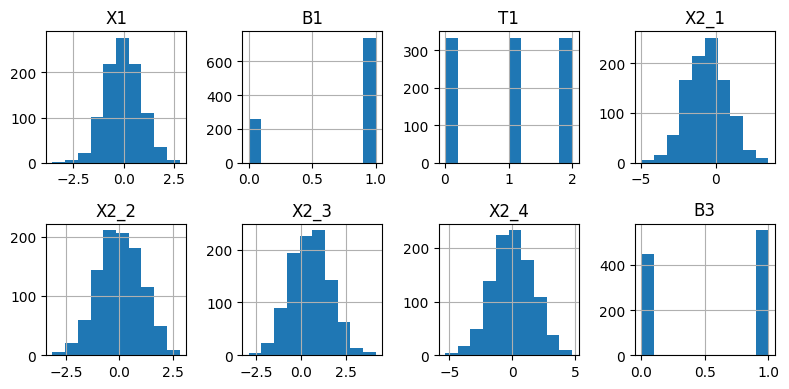

In [4]:
X.hist(layout=(2, 4), figsize=(8, 4))
plt.tight_layout()
plt.show()

### Classify test data variables into three subsets
We classify test data variables into three subsets: exogenous variables, endogenous variables, and the sink variable.

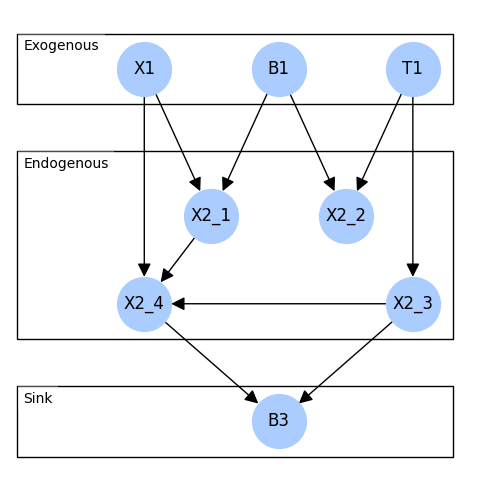

In [5]:
def add_fixed_box(ax, box, label, *, padding=0.01):
    x0, y0, w, h = box
    rect = patches.Rectangle((x0, y0), w, h, fill=False)
    ax.add_patch(rect)
    ax.text(
        x0 + padding, y0 + h - padding, label,
        ha='left', va='top',
        bbox=dict(facecolor='white', alpha=0.3, edgecolor='none')
    )
    return rect

# Node positions
POS = {
    'X1': (0.2, 0.8),
    'B1': (0.4, 0.8),
    'T1': (0.6, 0.8),
    'X2_1': (0.3, 0.55),
    'X2_2': (0.5, 0.55),
    'X2_3': (0.6, 0.4),
    'X2_4': (0.2, 0.4),
    'B3': (0.4, 0.2),
}

B_true = pd.DataFrame([
    [0,  0,  0,  1,  0,  0,  1,  0],
    [0,  0,  0,  1,  1,  0,  0,  0],
    [0,  0,  0,  0,  1,  1,  0,  0],
    [0,  0,  0,  0,  0,  0,  1,  0],
    [0,  0,  0,  0,  0,  0,  0,  0],
    [0,  0,  0,  0,  0,  0,  1,  1],
    [0,  0,  0,  0,  0,  0,  0,  1],
    [0,  0,  0,  0,  0,  0,  0,  0]
], index=NODE_NAMES, columns=NODE_NAMES)

G_true = nx.from_pandas_adjacency(B_true, create_using=nx.DiGraph)

# Draw a causal graph
fig, ax = plt.subplots(figsize=(5, 5))
nx.draw(
    G_true, POS,
    with_labels=True,
    node_color='#AACCFF',
    node_size=1500,
    arrowsize=20,
    min_target_margin=18,
    ax=ax
)

xs, ys = map(np.array, zip(*POS.values()))
ax.set_xlim(xs.min() - 0.20, xs.max() + 0.10)
ax.set_ylim(ys.min() - 0.10, ys.max() + 0.10)

# Draw grouping boxes
add_fixed_box(ax, (0.01, 0.74, 0.65, 0.12), 'Exogenous')
add_fixed_box(ax, (0.01, 0.34, 0.65, 0.32), 'Endogenous')
add_fixed_box(ax, (0.01, 0.14, 0.65, 0.12), 'Sink')

ax.set_axis_off()
plt.tight_layout()
plt.show()

## Setting prior knowledge
Based on a three-layer structure of exogenous, endogenous, and sink variables, reverse-direction edges are prohibited.

In [6]:
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode

exog_var_names = ['X1', 'B1', 'T1']
endog_var_names = ['X2_1', 'X2_2', 'X2_3', 'X2_4']
sink_var_name = 'B3'

all_names = exog_var_names + endog_var_names + [sink_var_name]
nodes = {name: GraphNode(name) for name in all_names}

# Setting prior knowledge
bk = BackgroundKnowledge()

# Prohibit edges Endogenous -> Exogenous
for endog in endog_var_names:
    for exog in exog_var_names:
        bk.add_forbidden_by_node(nodes[endog], nodes[exog])

# Prohibit edges Exogenous <-> Sink
for exog in exog_var_names:
    bk.add_forbidden_by_node(nodes[sink_var_name], nodes[exog])
    bk.add_forbidden_by_node(nodes[endog], nodes[sink_var_name])

# Prohibit edges Sink -> Endogenous
for endog in endog_var_names:
    bk.add_forbidden_by_node(nodes[sink_var_name], nodes[endog])

## PC algorithm

In [7]:
%%time
from causallearn.search.ConstraintBased.PC import pc

pccg = pc(
    X.values,
    node_names=NODE_NAMES,
    is_discrete=[False, True, True, False, False, False, False, True],
    indep_test='kci', # Use KCI for the independence test
    background_knowledge=bk,
    show_progress=False, 
    verbose=False
)

adjacency_matrix = pccg.G.graph
B_est = pd.DataFrame(adjacency_matrix, index=NODE_NAMES, columns=NODE_NAMES)
B_est

CPU times: total: 24.4 s
Wall time: 1min 40s


,X1,B1,T1,X2_1,X2_2,X2_3,X2_4,B3
X1,0,0,0,-1,0,0,-1,0
B1,0,0,0,-1,-1,0,0,0
T1,0,0,0,0,-1,-1,0,0
X2_1,1,1,0,0,0,0,-1,-1
X2_2,0,1,1,0,0,0,0,0
X2_3,0,0,1,0,0,0,-1,-1
X2_4,1,0,0,1,0,1,0,0
B3,0,0,0,1,0,1,0,0


## Visualize a result
The causal graph is as follows:

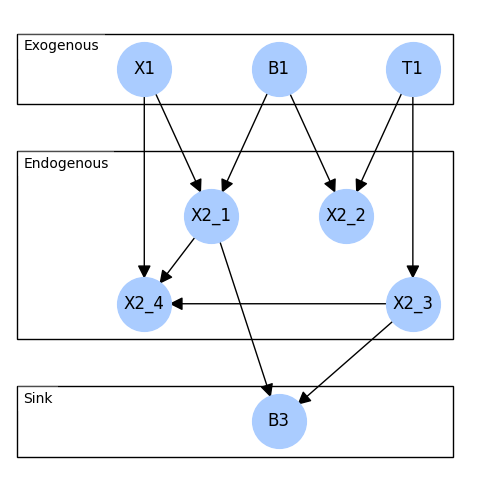

In [8]:
directed_edges = []
undirected_edges = []

n_variables = len(NODE_NAMES)
for i in range(n_variables):
    for j in range(i+1, n_variables):
        a_ij = adjacency_matrix[i, j]
        a_ji = adjacency_matrix[j, i]

        if a_ij == -1 and a_ji == 1: # i -> j
            directed_edges.append((NODE_NAMES[i], NODE_NAMES[j]))
        elif a_ij == 1 and a_ji == -1: # j -> i
            directed_edges.append((NODE_NAMES[j], NODE_NAMES[i]))
        elif a_ij == -1 and a_ji == -1: # Undirected
            undirected_edges.append((NODE_NAMES[i], NODE_NAMES[j]))

# Separate the directed and undirected graphs
G_directed = nx.DiGraph()
G_undirected = nx.Graph()

G_directed.add_nodes_from(NODE_NAMES)
G_undirected.add_nodes_from(NODE_NAMES)

G_directed.add_edges_from(directed_edges)
G_undirected.add_edges_from(undirected_edges)

# Draw a causal graph
fig, ax = plt.subplots(figsize=(5, 5))
nx.draw_networkx_nodes(G_directed, POS, node_color='#AACCFF', node_size=1500, ax=ax)
nx.draw_networkx_labels(G_directed, POS, ax=ax)

# Undirected edge (dashed line)
nx.draw_networkx_edges(
    G_undirected, POS,
    style='dashed',
    ax=ax
)

# Directed edge (arrow)
nx.draw_networkx_edges(
    G_directed, POS,
    arrowsize=20,
    min_target_margin=18,
    ax=ax
)

xs, ys = map(np.array, zip(*POS.values()))
ax.set_xlim(xs.min() - 0.20, xs.max() + 0.10)
ax.set_ylim(ys.min() - 0.10, ys.max() + 0.10)

# Draw grouping boxes
add_fixed_box(ax, (0.01, 0.74, 0.65, 0.12), 'Exogenous')
add_fixed_box(ax, (0.01, 0.34, 0.65, 0.32), 'Endogenous')
add_fixed_box(ax, (0.01, 0.14, 0.65, 0.12), 'Sink')

ax.set_axis_off()
plt.tight_layout()
plt.show()

## Perform bootstrapping

In [9]:
from sklearn.utils import resample

def bootstrap(X, n_sampling=100):
    rng = np.random.default_rng(0)
    results = []
    for i in range(n_sampling):
        seed_i = int(rng.integers(2**32))
        resampled_X = resample(X, random_state=seed_i)
        pccg = pc(
            resampled_X.values,
            node_names=NODE_NAMES,
            is_discrete=[False, True, True, False, False, False, False, True],
            indep_test='kci', # Use KCI for the independence test
            background_knowledge=bk,
            show_progress=False, 
            verbose=False
        )
        results.append(pccg.G) # Save the results

    return results

In [10]:
%%time
results = bootstrap(X, n_sampling=100)

CPU times: total: 1h 16min 37s
Wall time: 5h 39min 52s


## Compute precision, recall, and F1

In [11]:
from causallearn.graph.GeneralGraph import GeneralGraph

# Convert the true causal graph to a GeneralGraph
A = np.asarray(B_true.values)
nodes = [GraphNode(name) for name in NODE_NAMES]
G_true_graph = GeneralGraph(nodes)

for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        if i != j and A[i, j] == 1:
            G_true_graph.add_directed_edge(nodes[i], nodes[j])  # i -> j

In [12]:
from causallearn.graph.AdjacencyConfusion import AdjacencyConfusion
from causallearn.graph.ArrowConfusion import ArrowConfusion

rows = []
for G_est_graph in results:
    # Compute with edge skeleton
    adjacency_confusion = AdjacencyConfusion(G_true_graph, G_est_graph)
    precision_skeleton = adjacency_confusion.get_adj_precision()
    recall_skeleton = adjacency_confusion.get_adj_recall()
    f1_skeleton = 0.0 if (precision_skeleton + recall_skeleton) == 0 else 2 * precision_skeleton * recall_skeleton / (precision_skeleton + recall_skeleton)
    # Compute with edge directions
    arrow_confusion = ArrowConfusion(G_true_graph, G_est_graph)
    precision_directed = arrow_confusion.get_arrows_precision()
    recall_directed  = arrow_confusion.get_arrows_recall()
    f1_directed = 0.0 if (precision_directed + recall_directed) == 0 else 2 * precision_directed * recall_directed / (precision_directed + recall_directed)
    # Save the results
    rows.append({
        "precision_skeleton": precision_skeleton, "recall_skeleton": recall_skeleton, "f1_skeleton": f1_skeleton,
        "precision_directed": precision_directed, "recall_directed": recall_directed, "f1_directed": f1_directed
    })

df_results = pd.DataFrame(rows)
df_results.head()

,precision_skeleton,recall_skeleton,f1_skeleton,precision_directed,recall_directed,f1_directed
0,0.750000,0.9,0.818182,0.750000,0.9,0.818182
1,0.818182,0.9,0.857143,0.818182,0.9,0.857143
2,0.818182,0.9,0.857143,0.818182,0.9,0.857143
3,0.818182,0.9,0.857143,0.818182,0.9,0.857143
4,0.818182,0.9,0.857143,0.818182,0.9,0.857143


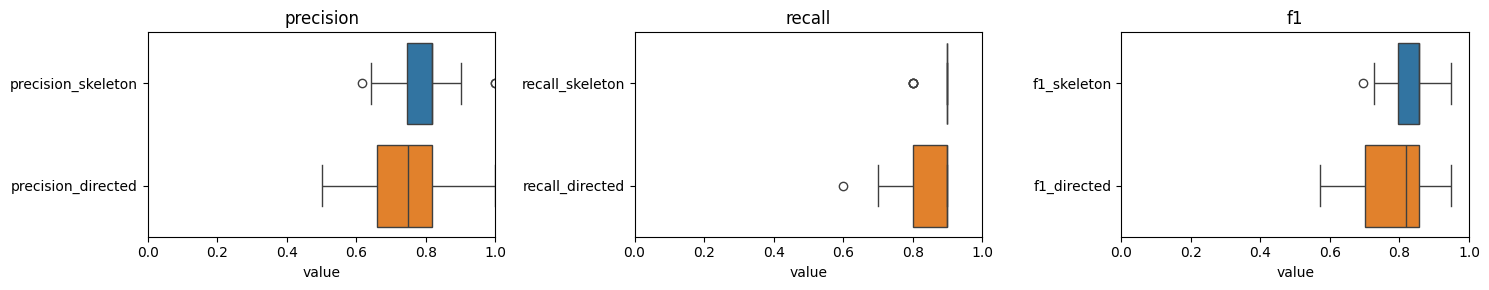

In [13]:
pairs = {
    'precision': ['precision_skeleton', 'precision_directed'],
    'recall':    ['recall_skeleton', 'recall_directed'],
    'f1':        ['f1_skeleton', 'f1_directed'],
}

# Show box plots
fig, axes = plt.subplots(1, 3, figsize=(15, 3), sharex=True)
for ax, (metric, cols) in zip(axes, pairs.items()):
    sns.boxplot(data=df_results[cols], orient='h', ax=ax)
    ax.set_title(metric)
    ax.set_xlim(0, 1)
    ax.set_xlabel('value')
plt.tight_layout()
plt.show()

## Directed edge counts (excluding bidirectional edges)

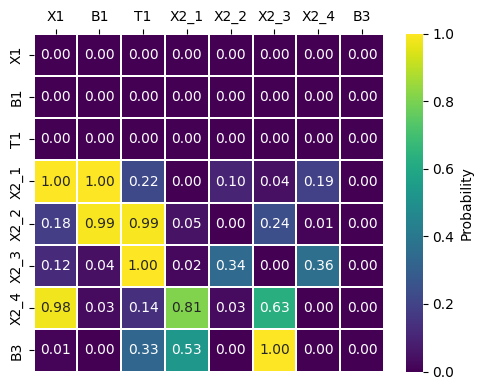

In [14]:
n = len(NODE_NAMES)
counts = np.zeros((n, n), dtype=float)
for G_est_graph in results:
    A = G_est_graph.graph
    edge_ij = ((A == 1) & (A.T == -1)).astype(float)
    counts += edge_ij

prob = counts / len(results)
prob_df = pd.DataFrame(prob, index=NODE_NAMES, columns=NODE_NAMES)

plt.figure(figsize=(5, 4))
ax = sns.heatmap(prob_df, cmap='viridis', linewidths=0.3, linecolor='white', fmt='.2f', annot=True, cbar_kws={'label': 'Probability'})
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
plt.tight_layout()
plt.show()